In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

# Set a nice style for the plots
sns.set_theme(style="whitegrid", palette="viridis")

In [2]:
try:
    data = pd.read_csv("bankura_wheat_detailed.csv")
    print("✅ Dataset loaded successfully!")
    display(data.head())
except FileNotFoundError:
    print("❌ Error: 'bankura_wheat_detailed.csv' not found.")
    print("Please make sure the CSV file is in the same directory as your Jupyter Notebook.")

✅ Dataset loaded successfully!


,Year,District,Wheat_Yield_t_ha,year,week_1_precip,week_1_LST,week_2_precip,week_2_LST,week_3_precip,week_3_LST,...,fortnight_7_precip,fortnight_7_LST,fortnight_8_precip,fortnight_8_LST,fortnight_9_precip,fortnight_9_LST,fortnight_10_precip,fortnight_10_LST,fortnight_11_precip,fortnight_11_LST
0,2001,Bankura,2.425,2001,0.000000,30.205143,0.000000,29.356571,0.0,26.550571,...,0.000000,30.830929,1.479643,31.752143,0.000000,36.067286,2.765214,34.706714,0.743833,35.792083
1,2002,Bankura,2.470,2002,0.003000,29.035714,0.000000,27.504571,0.0,26.874571,...,0.495214,28.736929,0.441286,32.055286,0.771071,34.149000,0.925786,19.060929,0.960583,33.695417
2,2003,Bankura,2.582,2003,0.000000,27.376286,0.000000,27.356571,0.0,26.379143,...,0.561214,26.870357,0.000000,30.876857,4.167000,30.839071,0.067786,32.530429,1.760750,34.737500
3,2004,Bankura,2.688,2004,0.004571,27.358286,0.000429,26.208143,0.0,25.116571,...,0.051214,28.055214,0.000500,33.127643,0.022143,34.405071,1.806857,36.295714,2.129846,34.975538
4,2005,Bankura,2.648,2005,0.009714,27.176143,0.000000,27.300429,0.0,26.503714,...,1.336500,29.370714,0.056000,31.440429,2.330786,33.169857,0.781714,33.096429,0.438750,35.231917


In [3]:
# The name of your yield column
YIELD_COLUMN_NAME = 'Wheat_Yield_t_ha'

# Identify feature columns automatically
# We exclude metadata columns and the target variable
exclude_cols = ['Year', 'District', 'Wheat_Yield_t_ha', 'year']
features = [col for col in data.columns if col not in exclude_cols]

print(f"Identified {len(features)} features for modeling.")

# Drop any rows with missing data to ensure the model runs smoothly
data.dropna(subset=features + [YIELD_COLUMN_NAME], inplace=True)

X = data[features]
y = data[YIELD_COLUMN_NAME]

# Split the data into 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data prepared for modeling:")
print(f"Number of training samples: {len(X_train)}")
print(f"Number of testing samples: {len(X_test)}")

Identified 66 features for modeling.
Data prepared for modeling:
Number of training samples: 19
Number of testing samples: 5


In [4]:
# Initialize the model with 100 decision trees
# random_state=42 ensures that the results are reproducible
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train (fit) the model on the training data
rf_model.fit(X_train, y_train)

print("✅ Random Forest model has been successfully trained!")

✅ Random Forest model has been successfully trained!


In [5]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Calculate performance metrics
mae = metrics.mean_absolute_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)

print("📈 Model Performance Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"R-squared (R²): {r2:.3f}")
print(f"\nThis means our model can explain {r2:.1%} of the variance in wheat yield.")

📈 Model Performance Evaluation:
Mean Absolute Error (MAE): 0.185
R-squared (R²): 0.084

This means our model can explain 8.4% of the variance in wheat yield.



🔍 Top 20 Feature Importance Rankings:


,Feature,Importance
32,week_17_precip,0.116347
36,week_19_precip,0.068301
7,week_4_LST,0.066980
9,week_5_LST,0.055288
28,week_15_precip,0.044254
2,week_2_precip,0.040658
14,week_8_precip,0.038689
63,fortnight_10_LST,0.037166
22,week_12_precip,0.037062
18,week_10_precip,0.035019


C:\Users\RAIKAT\AppData\Local\Temp\ipykernel_575048\1459942111.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='plasma')


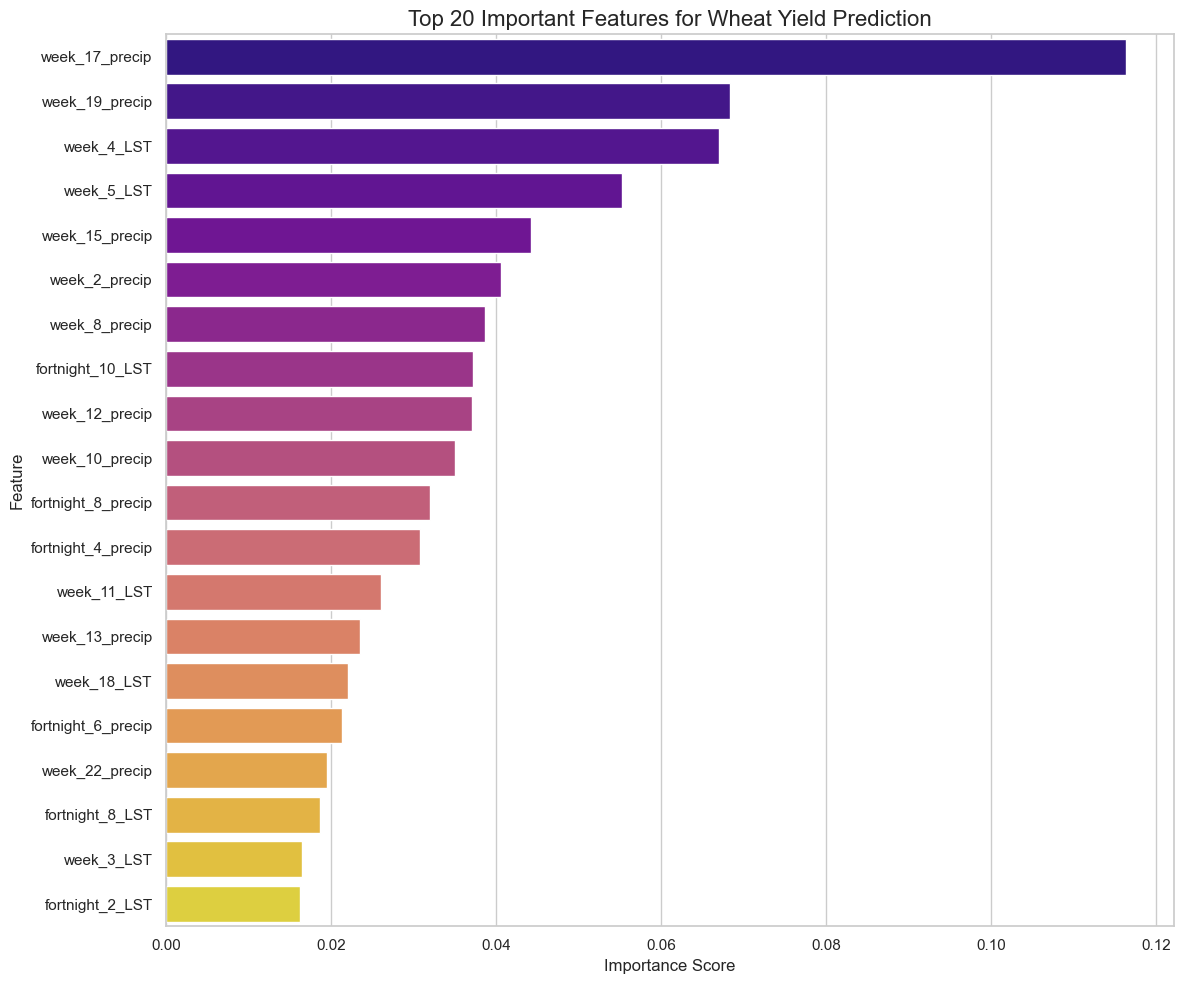

In [6]:
# Get feature importances
importances = rf_model.feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display top 20 features
print("\n🔍 Top 20 Feature Importance Rankings:")
display(feature_importance_df.head(20))

# Plot the top 20 features
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='plasma')
plt.title('Top 20 Important Features for Wheat Yield Prediction', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

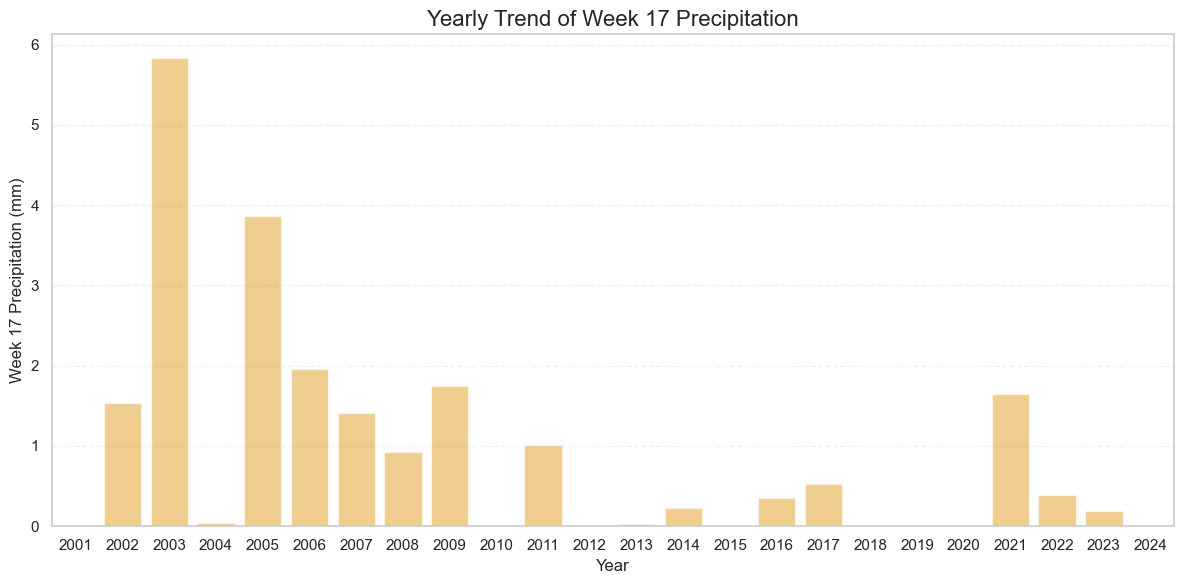

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load your dataset
data = pd.read_csv("bankura_wheat_detailed.csv")

plt.figure(figsize=(12, 6))

# Bar plot for Week 17 precipitation
sns.barplot(
    x='Year', 
    y='week_17_precip', 
    data=data, 
    alpha=0.5, 
    color='orange'
)

plt.ylabel("Week 17 Precipitation (mm)", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.title("Yearly Trend of Week 17 Precipitation", fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


C:\Users\RAIKAT\AppData\Local\Temp\ipykernel_575048\3033602496.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Category", y="Avg_Week17_Precip", data=avg_df, palette=["red", "green"])


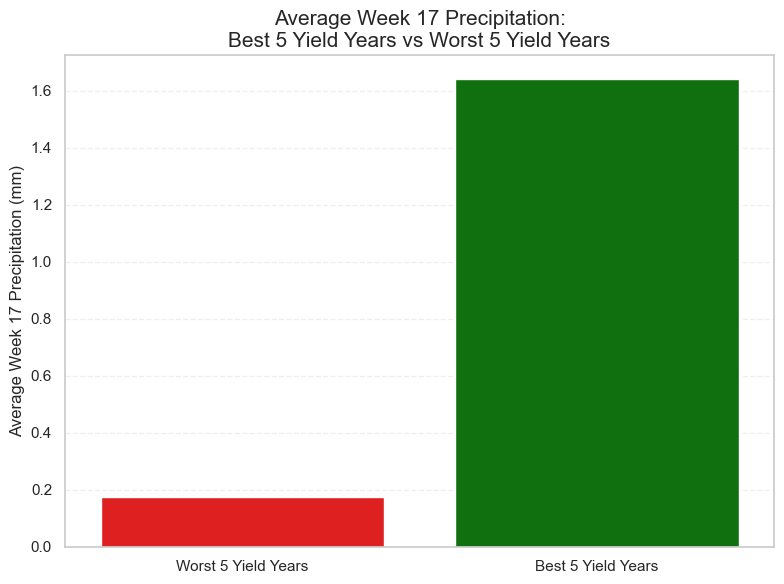

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("bankura_wheat_detailed.csv")

# If multiple districts exist, aggregate per year
# data = data.groupby("Year", as_index=False).agg({
#     "Wheat_Yield_t_ha": "mean",
#     "week_17_precip": "mean"
# })

# Sort by yield
sorted_data = data.sort_values("Wheat_Yield_t_ha")

# Select best 5 and worst 5 years
worst5 = sorted_data.head(5)
best5 = sorted_data.tail(5)

# Compute averages
avg_worst = worst5["week_17_precip"].mean()
avg_best = best5["week_17_precip"].mean()

# Create a dataframe for plotting
avg_df = pd.DataFrame({
    "Category": ["Worst 5 Yield Years", "Best 5 Yield Years"],
    "Avg_Week17_Precip": [avg_worst, avg_best]
})

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(x="Category", y="Avg_Week17_Precip", data=avg_df, palette=["red", "green"])

plt.ylabel("Average Week 17 Precipitation (mm)", fontsize=12)
plt.xlabel("")
plt.title("Average Week 17 Precipitation:\nBest 5 Yield Years vs Worst 5 Yield Years", fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()
